<a href="https://colab.research.google.com/github/ActLuisGutierrezVanegas/Image_classification_PyTorch_Cats_vs_Dogs/blob/main/Image_clasification_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Configuración

## Configuración para leer archivos locales

In [2]:
# Configuración necesaria para poder leer los archivos desde mi unidad de Drive.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Librerías

In [3]:
# Sistema/Entorno local
import os
# Manipulación de datos
import random
import numpy as np
# Visualización
import matplotlib.pyplot as plt
# Image Pillow
from PIL import Image, ImageFile
# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as dset
import torchvision.transforms as transforms

# 1.- Carga de la base de datos de imágenes

In [4]:
# Indicamos la ruta donde se encuentran los archivos en la unidad de Drive.
raiz = "/content/drive/MyDrive/TLG_CertificacionDataScientist/"
sufijoComp = "Comp7_ML_para_BigData"
sufijoMicroComp = "MicroC_7_3_Deep_Learning_PyTorch/"

directorio = "catsvsdogs"
modelo = "cnn_clasifier_cats_dogs.pth"

path = f"{raiz}{sufijoComp}/{sufijoMicroComp}/{directorio}/"
pathModelo = f"{raiz}{sufijoComp}/{sufijoMicroComp}{modelo}"

In [5]:
# Validamos que existen las carpetas en la ruta.
print(os.listdir(path))

['dogs', 'cats']


In [6]:
# Validamos la cantidad de imágenes en cada carpeta.
clases = ['cats', 'dogs']

In [7]:
# Obtenemos las clases y tamaño de cada clase.
suma = 0
for clase in clases:
    carpeta = os.path.join(path, clase)
    cantidad = len(os.listdir(carpeta))

    print(clase, "->", cantidad, "archivos")

    suma += cantidad

cats -> 2403 archivos
dogs -> 2495 archivos


Tenemos clases equilibradas.

In [8]:
print("Total de archivos:", suma)

Total de archivos: 4898


In [9]:
# Fijamos semilla para reproducir.
SEED = 32

In [10]:
# Visualización de una imagen de cada clase.
ruta_cats = os.path.join(path, "cats")
ruta_dogs = os.path.join(path, "dogs")
archivo_dog = os.listdir(ruta_dogs)[SEED]
archivo_cat = os.listdir(ruta_cats)[SEED]
imagen_cat = Image.open(os.path.join(ruta_cats, archivo_cat))
imagen_dog = Image.open(os.path.join(ruta_dogs, archivo_dog))

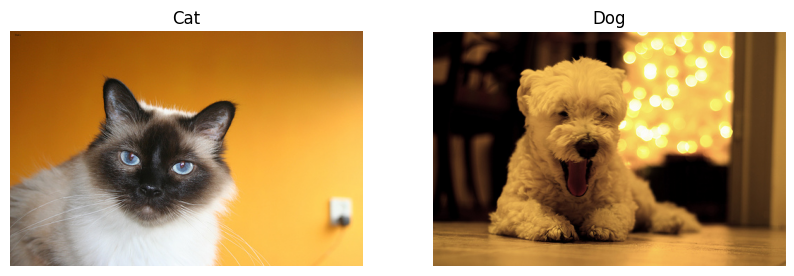

In [11]:
# Visualizamos las imágenes muestra.
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen_cat)
plt.title("Cat")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_dog)
plt.title("Dog")
plt.axis("off")

plt.show()

# 2.- Pre-procesamiento de la base de datos de imágenes

In [12]:
# Fijamos la semilla previamente creada en los generadores aleatorios para poderreproducir los resultados más adelante.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [13]:
# Transformaciones aplicadas a todas las imágenes: Se redimensionan a 64x64 píxeles. Y se convierten a tensores de PyTorch.
# Se elige el tamaño de 64 x 64 para un balance entre costo computacional y preservar información visual relevante para la arquitectura del modelo.
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [14]:
# Cargamos el conjunto de datos e ImageFolder asigna automáticamente una etiqueta a cada carpeta/clase.
dataset = dset.ImageFolder(
    root = path,
    transform = transform
)

In [15]:
# Validamos la cantidad de archivos.
print(dataset.classes)
print(dataset.class_to_idx)
print(len(dataset))

['cats', 'dogs']
{'cats': 0, 'dogs': 1}
4895


In [16]:
# Definimos las proporciones de los conjuntos: 70% entrenamiento, 15% validación y 15% prueba.
TOTAL = len(dataset)
NUM_TRAIN = int(TOTAL * 0.70)
NUM_VAL = int(TOTAL * 0.15)
NUM_TEST = TOTAL - NUM_TRAIN - NUM_VAL

In [63]:
# Validamos la cantidad de archivos por conjunto.
print(f"Cantidad imágenes entrenamiento: {NUM_TRAIN}")
print(f"Cantidad imágenes validación: {NUM_VAL}")
print(f"Cantidad imágenes test: {NUM_TEST}")

Cantidad imágenes entrenamiento: 3426
Cantidad imágenes validación: 734
Cantidad imágenes test: 735


In [18]:
# Generamos y mezclamos los índices de las imágenes.
indices = np.arange(TOTAL)
np.random.seed(SEED)
np.random.shuffle(indices)

In [19]:
# Separamos los índices de cada conjunto.
train_idx = indices[: NUM_TRAIN]
val_idx = indices[NUM_TRAIN: NUM_TRAIN + NUM_VAL]
test_idx = indices[NUM_TRAIN + NUM_VAL: ]

In [20]:
# Creamos los DataLoader (minibatch).
# Cada minibatch contendrá hasta máximo 64 imágenes.
train_data = DataLoader(
    dataset,
    batch_size = 64,
    sampler = sampler.SubsetRandomSampler(train_idx)
)

val_data = DataLoader(
    dataset,
    batch_size = 64,
    sampler = sampler.SubsetRandomSampler(val_idx)
)

test_data = DataLoader(
    dataset,
    batch_size = 64,
    sampler = sampler.SubsetRandomSampler(test_idx)
)

In [21]:
# Validamos las dimensiones de un minibatch.
xi, yi = next(iter(train_data))
print("Dimensión minibatch de imágenes:", xi.shape)
print("Dimensión minibatch de etiquetas:", yi.shape)

Dimensión minibatch de imágenes: torch.Size([64, 3, 64, 64])
Dimensión minibatch de etiquetas: torch.Size([64])


# 3.- Config GPU para modelo de entrenamiento

In [22]:
# Seleccionamos GPU si está disponible; en caso contrario se utilizará CPU.
# CUDA (Compute Unified Device Architecture).
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


# 4.- Modelo: Red Neuronal Convolucional - CNN

## Función de entrenamiento

In [23]:
def train(
    model,
    optimiser,
    train_data,
    val_data,
    epochs=20
):
    # Visualizamos los resultados para cada época.
    for epoch in range(epochs):
        # Variable auxiliar para el costo total de pérdida por época.
        total_cost = 0
        # Activamos el modelo.
        model.train()
        # Vamos recorriendo los batches previamente creados.
        for xi, yi in train_data:
            #Pasamos los datos a la GPU.
            xi = xi.to(
                device = device,
                dtype = torch.float32
            )
            yi = yi.to(
                device = device,
                dtype = torch.long
            )
            # Forward pass
            scores = model(xi)
            # Función de pérdida (error).
            cost = F.cross_entropy(
                input = scores,
                target = yi
            )
            # Limpiamos los gradientes por minibatch.
            optimiser.zero_grad()
            # Backpropagation.
            cost.backward()
            # El optimizador actualiza los pesos.
            optimiser.step()
            # Sumamos el costo de cada minibatch.
            total_cost += cost.item()
        # Calculamos el costo de pérdida promedio.
        average_cost = total_cost / len(train_data)
        print(
            f"Epoch: {epoch}, "
            # Costo de pérdida promedio por época.
            f"costo promedio: {average_cost:.4f}, "
            # Métricas
            f"accuracy: {accuracy(model, val_data):.4f}, "
            f"precision: {precision(model, val_data):.4f}, "
            f"recall: {recall(model, val_data):.4f}, "
            f"f1: {f1_score(model, val_data):.4f}"
        )

## Funciones de métricas


In [24]:
def accuracy(model, data_loader):
    num_correct = 0
    num_total = 0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for (xi, yi) in data_loader:
            xi = xi.to(
                device = device,
                dtype = torch.float32
            )
            yi = yi.to(
                device = device,
                dtype = torch.long
            )
            scores = model(xi)
            _, pred = scores.max(dim=1)
            num_correct += (pred == yi.squeeze()).sum().item()
            num_total += pred.size(0)
    return num_correct / num_total

In [25]:
def precision(model, data_loader):
    true_positive = 0
    false_positive = 0
    model.eval()
    model = model.to(device = device)
    with torch.no_grad():
        for (xi, yi) in data_loader:
            xi = xi.to(
                device = device,
                dtype = torch.float32
            )
            yi = yi.to(
                device = device,
                dtype = torch.long
            )
            scores = model(xi)
            _, pred = scores.max(dim=1)
            true_positive += (
                (pred == 1) & (yi == 1)
            ).sum().item()

            false_positive += (
                (pred == 1) & (yi == 0)
            ).sum().item()
    if (true_positive + false_positive) == 0:
        return 0
    return true_positive / (true_positive + false_positive)

In [26]:
def recall(model, data_loader):
    true_positive = 0
    false_negative = 0
    model.eval()
    model = model.to(device = device)
    with torch.no_grad():
        for (xi, yi) in data_loader:
            xi = xi.to(
                device = device,
                dtype = torch.float32
            )
            yi = yi.to(
                device = device,
                dtype = torch.long
            )
            scores = model(xi)
            _, pred = scores.max(dim = 1)
            true_positive += (
                (pred == 1) & (yi == 1)
            ).sum().item()
            false_negative += (
                (pred == 0) & (yi == 1)
            ).sum().item()
    if (true_positive + false_negative) == 0:
        return 0
    return true_positive / (true_positive + false_negative)

In [27]:
def f1_score(model, data_loader):
    precision_value = precision(
        model,
        data_loader
    )
    recall_value = recall(
        model,
        data_loader
    )
    if (precision_value + recall_value) == 0:
        return 0
    return (
        2
        * precision_value
        * recall_value
        / (precision_value + recall_value)
    )

In [34]:
def confusion_matrix_values(model, data_loader):
    true_negative = 0
    false_positive = 0
    false_negative = 0
    true_positive = 0
    model.eval()
    with torch.no_grad():
        for xi, yi in data_loader:
            xi = xi.to(
                device = device,
                dtype = torch.float32
            )
            yi = yi.to(
                device=device,
                dtype=torch.long
            )
            scores = model(xi)
            _, pred = scores.max(dim = 1)
            true_negative += (
                (pred == 0) & (yi == 0)
            ).sum().item()
            false_positive += (
                (pred == 1) & (yi == 0)
            ).sum().item()
            false_negative += (
                (pred == 0) & (yi == 1)
            ).sum().item()
            true_positive += (
                (pred == 1) & (yi == 1)
            ).sum().item()
    matrix = np.array([
        [true_negative, false_positive],
        [false_negative, true_positive]
    ])
    return matrix

In [33]:
def plot_confusion_matrix(matrix):
    plt.figure(figsize = (6, 5))
    plt.imshow(matrix, interpolation = 'nearest')
    plt.title("Matriz de confusión")
    plt.colorbar()
    class_names = ["Cat", "Dog"]
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(
                j, i,
                str(matrix[i, j]),
                ha="center",
                va="center"
            )
    plt.show()

## 1ra configuración (SGD)

In [ ]:
model_1 = nn.Sequential(

    # Primera capa convolucional.
    # Recibe 3 canales de entrada (R, G, B) y genera 16 mapas de características.
    nn.Conv2d(
        in_channels = 3,
        out_channels = 16,
        kernel_size = 3,
        stride = 1,
        padding = 1,
        bias = True
    ),

    # Función de activación no lineal ReLU.
    nn.ReLU(),
    # Capa de Max Pooling. Reduce las dimensiones espaciales de 64x64 a 32x32.
    nn.MaxPool2d((2, 2)),

    # Segunda capa convolucional.
    # Recibe los 16 mapas de características anteriores y genera 32 nuevos mapas de características.
    nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=True
    ),

    # Segunda activación ReLU.
    nn.ReLU(),
    # Segunda capa Max Pooling.Reduce las dimensiones espaciales de 32x32 a 16x16.
    nn.MaxPool2d((2, 2)),

    # Convierte los 32 mapas de características de 16x16
    nn.Flatten(),

    # Capa de salida: 16*16*32 = 8192 características de entrada.
    # Se generan 2 salidas, una para cada clase: cats y dogs.
    nn.Linear(
        in_features=16*16*32,
        out_features=2,
        bias=True
    )
)

In [ ]:
# Enviamos el modelo a la GPU.
model_1 = model_1.to(device)

In [ ]:
# Definimos el optimizador SGD con learning rate de 0.001.
# Este optimizador actualizará los pesos y bias del modelo utilizando los gradientes calculados durante backpropagation.
optimiser_1 = torch.optim.SGD(
    model_1.parameters(),
    lr = 1e-3
)

## 2da configuración (Adam)

In [28]:
# Se conserva la misma arquitectura CNN de la primera configuración para comparar el efecto del optimizador sobre el entrenamiento.

model_2 = nn.Sequential(

    # Primera capa convolucional.
    # Recibe 3 canales de entrada (R, G, B) y genera 16 mapas de características.
    nn.Conv2d(
        in_channels = 3,
        out_channels = 16,
        kernel_size = 3,
        stride = 1,
        padding = 1,
        bias = True
    ),

    # Función de activación no lineal ReLU.
    nn.ReLU(),
    # Capa de Max Pooling. Reduce las dimensiones espaciales de 64x64 a 32x32.
    nn.MaxPool2d((2, 2)),

    # Segunda capa convolucional.
    # Recibe los 16 mapas de características anteriores y genera 32 nuevos mapas de características.
    nn.Conv2d(
        in_channels = 16,
        out_channels = 32,
        kernel_size = 3,
        stride = 1,
        padding = 1,
        bias = True
    ),

    # Segunda activación ReLU.
    nn.ReLU(),
    # Segunda capa Max Pooling.Reduce las dimensiones espaciales de 32x32 a 16x16.
    nn.MaxPool2d((2, 2)),

    # Convierte los 32 mapas de características de 16x16
    nn.Flatten(),

    # Capa de salida: 16*16*32 = 8192 características de entrada.
    # Se generan 2 salidas, una para cada clase: cats y dogs.
    nn.Linear(
        in_features = 16*16*32,
        out_features = 2,
        bias = True
    )
)

In [29]:
# Enviamos el modelo a la GPU.
model_2 = model_2.to(device)

In [30]:
# Definimos el optimizador Adam con learning rate de 0.001.
# Adam ajusta los pesos y bias utilizando los gradientes calculados durante el proceso de backpropagation.
optimiser_2 = torch.optim.Adam(
    model_2.parameters(),
    lr = 1e-3
)

# 5.- Entrenamiento

## 1er entrenamiento (Optimizer SDG)

In [ ]:
train(
    model = model_1,
    optimiser = optimiser_1,
    train_data = train_data,
    val_data = val_data,
    epochs = 20
)

Epoch: 0, costo: 0.6916, accuracy validación: 0.4946
Epoch: 1, costo: 0.6841, accuracy validación: 0.5041
Epoch: 2, costo: 0.6849, accuracy validación: 0.5109
Epoch: 3, costo: 0.6927, accuracy validación: 0.4959
Epoch: 4, costo: 0.6884, accuracy validación: 0.5409
Epoch: 5, costo: 0.7018, accuracy validación: 0.5654
Epoch: 6, costo: 0.6771, accuracy validación: 0.5150
Epoch: 7, costo: 0.6738, accuracy validación: 0.4932
Epoch: 8, costo: 0.7001, accuracy validación: 0.5204
Epoch: 9, costo: 0.6792, accuracy validación: 0.5463
Epoch: 10, costo: 0.6590, accuracy validación: 0.4891
Epoch: 11, costo: 0.6848, accuracy validación: 0.5572
Epoch: 12, costo: 0.6848, accuracy validación: 0.5463
Epoch: 13, costo: 0.6846, accuracy validación: 0.5559
Epoch: 14, costo: 0.6835, accuracy validación: 0.5450
Epoch: 15, costo: 0.6981, accuracy validación: 0.5518
Epoch: 16, costo: 0.6943, accuracy validación: 0.5504
Epoch: 17, costo: 0.6805, accuracy validación: 0.5463
Epoch: 18, costo: 0.6818, accuracy val

In [ ]:
print(f"Accuracy:  {accuracy(model_1, test_data):.4f}")
print(f"Precision: {precision(model_1, test_data):.4f}")
print(f"Recall:    {recall(model_1, test_data):.4f}")
print(f"F1 Score:  {f1_score(model_1, test_data):.4f}")

Accuracy:  0.5374
Precision: 0.5346
Recall:    0.7942
F1 Score:  0.6391


## 2do entrenamiento (Optimizer Adam)

In [31]:
train(
    model = model_2,
    optimiser = optimiser_2,
    train_data = train_data,
    val_data = val_data,
    epochs = 20
)

Epoch: 0, costo promedio: 0.6992, accuracy: 0.5286, precision: 0.5108, recall: 0.9167, f1: 0.6561
Epoch: 1, costo promedio: 0.6579, accuracy: 0.5981, precision: 0.5619, recall: 0.8194, f1: 0.6667
Epoch: 2, costo promedio: 0.6136, accuracy: 0.6553, precision: 0.6259, recall: 0.7389, f1: 0.6777
Epoch: 3, costo promedio: 0.5921, accuracy: 0.6730, precision: 0.6327, recall: 0.7944, f1: 0.7044
Epoch: 4, costo promedio: 0.5647, accuracy: 0.6839, precision: 0.6435, recall: 0.7972, f1: 0.7122
Epoch: 5, costo promedio: 0.5546, accuracy: 0.6921, precision: 0.6893, recall: 0.6778, f1: 0.6835
Epoch: 6, costo promedio: 0.5432, accuracy: 0.6757, precision: 0.6282, recall: 0.8306, f1: 0.7153
Epoch: 7, costo promedio: 0.5242, accuracy: 0.6948, precision: 0.6589, recall: 0.7833, f1: 0.7157
Epoch: 8, costo promedio: 0.5263, accuracy: 0.6975, precision: 0.6667, recall: 0.7667, f1: 0.7132
Epoch: 9, costo promedio: 0.4975, accuracy: 0.7166, precision: 0.7147, recall: 0.7028, f1: 0.7087
Epoch: 10, costo pro

Dado que las clases se encuentran balanceadas, se utiliza Accuracy como métrica principal para evaluar el rendimiento general del modelo. Adicionalmente, se considera el F1-score para analizar el balance entre Precision y Recall.  

Con el conjunto de validación, el mejor accuracy fue en la época 17 (0.7371) y el mejor F1-score fue en la época 13 (0.7346).

### Evaluamos el modelo

In [32]:
# Al modelo anterior le pasamos el conjunto de prueba para generar métricas y evaluar rendimiento.
print(f"Accuracy:  {accuracy(model_2, test_data):.4f}")
print(f"Precision: {precision(model_2, test_data):.4f}")
print(f"Recall:    {recall(model_2, test_data):.4f}")
print(f"F1 Score:  {f1_score(model_2, test_data):.4f}")

Accuracy:  0.7456
Precision: 0.7743
Recall:    0.7150
F1 Score:  0.7435


En el conjunto de prueba, el modelo obtuvo Accuracy (0.7456) y un F1-score (0.7435). Estos valores son consistentes con los obtenidos en la validación, lo que indica que el modelo mantiene un rendimiento estable sobre datos no vistos y presenta una capacidad adecuada de generalización sobre imágenes no antes vistas.

### Guardamos modelo

In [ ]:
# Guardamos el modelo en una ruta local, para su posterior uso.
torch.save(
    model_2.state_dict(),
    pathModelo
)

# 6.- Visualización de los resultados del entrenamiento

In [36]:
# Invocamos la función para obtener la matriz de confusión.
matrix_test = confusion_matrix_values(
    model_2,
    test_data
)

In [37]:
print(matrix_test)

[[277  79]
 [108 271]]


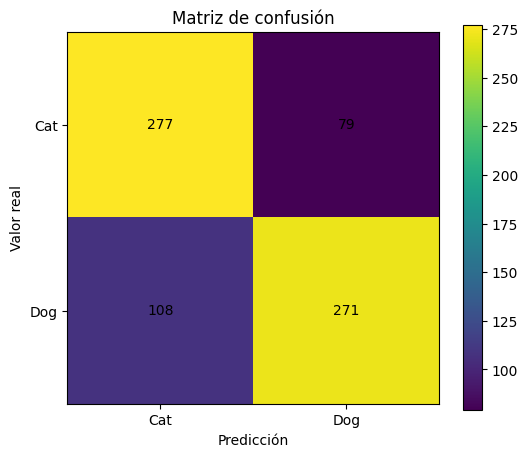

In [38]:
# De manera gráfica ilustramos la matriz de confusión.
plot_confusion_matrix(matrix_test)

# 7.- Carga del modelo

In [39]:
# Arquitectura para leer el modelo que guardamos previamente.
model_inferido = nn.Sequential(
    # Primera capa
    nn.Conv2d(
        in_channels = 3,
        out_channels = 16,
        kernel_size = 3,
        stride = 1,
        padding = 1,
        bias = True
    ),
    nn.ReLU(),
    nn.MaxPool2d((2, 2)),
    # Segunda capa.
    nn.Conv2d(
        in_channels = 16,
        out_channels = 32,
        kernel_size = 3,
        stride = 1,
        padding = 1,
        bias = True
    ),
    nn.ReLU(),
    nn.MaxPool2d((2, 2)),
    # Aplanamiento
    nn.Flatten(),
    nn.Linear(
        in_features = 16*16*32,
        out_features = 2,
        bias = True
    )
)

In [ ]:
# Seleccionamos GPU si está disponible; en caso contrario se utilizará CPU.
# CUDA (Compute Unified Device Architecture)
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [41]:
# Leemos el archivo .pth para cargar el modelo previamente entrenado.
model_inferido.load_state_dict(
    torch.load(
       pathModelo,
       map_location = device
    )
)

<All keys matched successfully>

In [43]:
# Mandamos el modelo a la GPU.
model_inferido = model_inferido.to(device)
model_inferido.eval()

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=8192, out_features=2, bias=True)
)

In [44]:
# Transformamos las imágenes a una resolución de 64 x 64.
transform_predict = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# 8.- Inferencia del modelo

In [57]:
def predict_image(image_path, model):
    # Cargamos las imágenes desde la ruta específicada.
    image = Image.open(image_path).convert("RGB")
    # Aplicamos las mismas transformaciones usadas para inferencia.
    image_tensor = transform_predict(image)
    # Agregamos la dimensión de batch y enviamos el tensor al dispositivo.
    image_tensor = image_tensor.unsqueeze(0).to(device)
    # Activamos el modo evaluación del modelo.
    model.eval()
    with torch.no_grad():
        # Obtenemos los logits del modelo.
        scores = model(image_tensor)
        # Convertimos los logits en probabilidades.
        probabilities = F.softmax(scores, dim = 1)
        # Obtenemos la clase con mayor probabilidad.
        probability, prediction = torch.max(
            probabilities,
            dim=1
        )
    # Clases del modelo.
    classes = ["Cat", "Dog"]
    # Probabilidades por clase.
    cat_probability = probabilities[0][0].item() * 100
    dog_probability = probabilities[0][1].item() * 100
    # Obtenemos la predicción y su nivel de confianza.
    predicted_class = classes[prediction.item()]
    confidence = probability.item() * 100
    # Visualización de resultados.
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Cat: {cat_probability:.2f}% | "
        f"Dog: {dog_probability:.2f}%"
    )
    plt.show()

    return (
        predicted_class,
        cat_probability,
        dog_probability
    )

In [50]:
# Leemos imagenes no antes vistas por el modelo en ningun conjunto.
directorioPrueba1 = "imagenesPrueba/imagenPruebaPytorch_1.jpg"
directorioPrueba2 = "imagenesPrueba/imagenPruebaPytorch_2.jpg"
directorioPrueba3 = "imagenesPrueba/imagenPruebaPytorch_3.jpg"
directorioPrueba4 = "imagenesPrueba/imagenPruebaPytorch_4.jpg"

pathImagen1 = f"{raiz}{sufijoComp}/{sufijoMicroComp}{directorioPrueba1}"
pathImagen2 =  f"{raiz}{sufijoComp}/{sufijoMicroComp}{directorioPrueba2}"
pathImagen3 = f"{raiz}{sufijoComp}/{sufijoMicroComp}{directorioPrueba3}"
pathImagen4 =  f"{raiz}{sufijoComp}/{sufijoMicroComp}{directorioPrueba4}"

## Clasificación de imagenes (Gatos vs Perros) con el modelo CNN (Optimizer Adam)

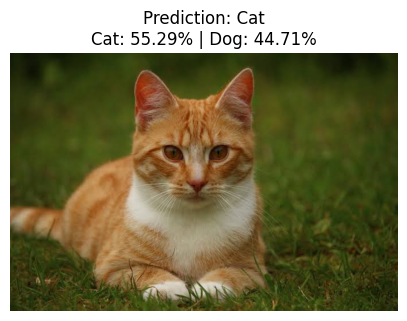

('Cat', 55.29487729072571, 44.70512568950653)

In [58]:
predict_image(
    pathImagen1,
    model_inferido
)

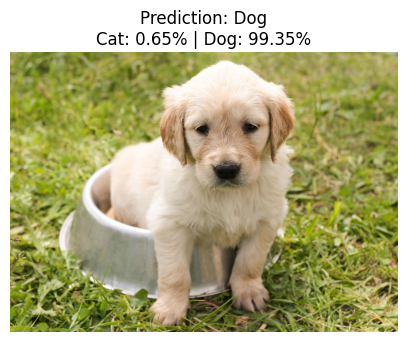

('Dog', 0.6501000840216875, 99.34990406036377)

In [60]:
predict_image(
    pathImagen2,
    model_inferido
)

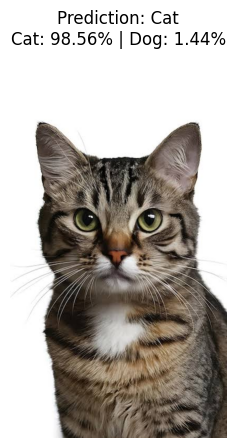

('Cat', 98.56106638908386, 1.4389407820999622)

In [61]:
predict_image(
    pathImagen4,
    model_inferido
)

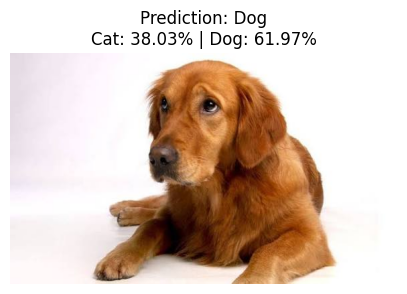

('Dog', 38.02826106548309, 61.97173595428467)

In [62]:
predict_image(
    pathImagen3,
    model_inferido
)